[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/key/lecture_3.2/StockChangeDistribution.ipynb)

_Run this notebook in the browser — no install needed._

# Stock change distribution

Daily percent changes in the S&P 500 index, compared with a normal
(bell-curve) distribution. This is the **fat-tailed** case: the middle
looks normal, but large moves happen far more often than a normal
distribution allows.

All three notebooks in this set (stock changes, human height, city
sizes) share `dist_tools.py`, so the plots and the summary table stay
identical across them.

In [1]:
# --- Make dist_tools.py importable ---------------------------------------
# Locally it sits next to this notebook. On Colab we grab it from GitHub.
import os, urllib.request
if not os.path.exists("dist_tools.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/BrainardLab/PythonTeachingCode"
        "/main/notebooks/key/lecture_3.2/dist_tools.py",
        "dist_tools.py",
    )

# Optional: pick up edits to dist_tools.py without restarting the kernel.
# Skipped silently where the autoreload extension is unavailable (e.g. the
# Python 3.13 build currently on Google Colab).
try:
    _ip = get_ipython()
    _ip.run_line_magic("load_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

import numpy as np
import pandas as pd
import dist_tools as dt

In [2]:
# Colab does not ship yfinance; %pip installs into the running kernel.
%pip install -q yfinance
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


In [3]:
ticker = "^GSPC"                     # S&P 500  (try "^DJI" for the Dow Jones)
raw = yf.download(ticker, start="2000-01-01", auto_adjust=True,
                  progress=False, multi_level_index=False)

prices = raw["Close"].dropna()      # daily closing index level, in points

# Daily percent change from the previous close. prices / prices.shift(1)
# is always positive, so this is always defined; it is simply negative
# on down days.
change = (prices.pct_change() * 100).dropna()

stock = dt.Distribution(
    values=change,
    quantity="Daily change in the S&P 500",
    unit="%",
    noun="trading days",
    source=f"Yahoo Finance via yfinance, ticker {ticker}",
    note=f"{change.index.min().date()} to {change.index.max().date()}",
    bin_width=0.5,
)

**The histogram on its own.** Look at the shape of the data first, with no
normal curve drawn on top. The same three panels appear again just below,
this time with the fit added.

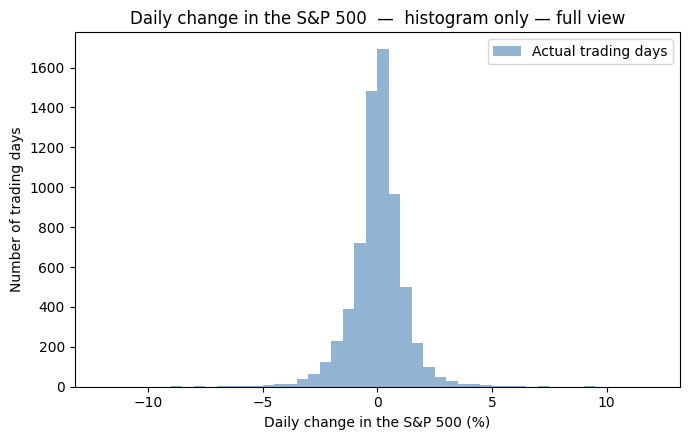

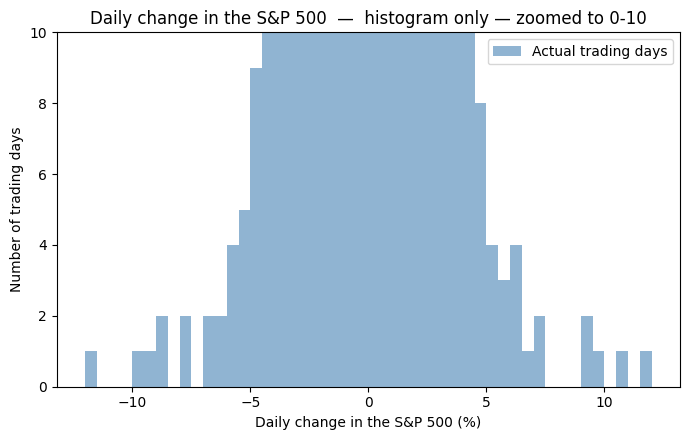

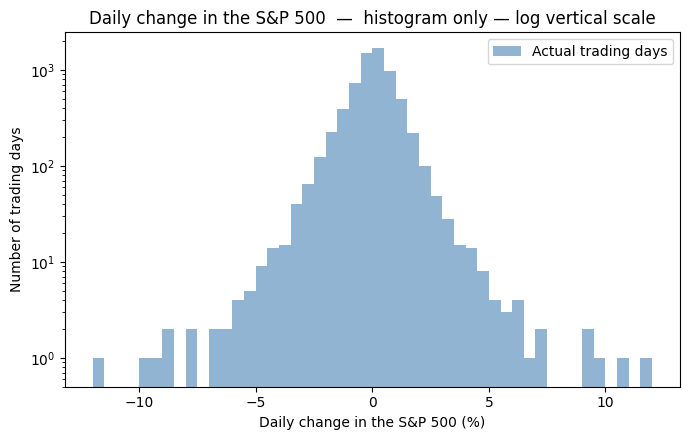

In [4]:
dt.raw_histogram(stock)

Source:  Yahoo Finance via yfinance, ticker ^GSPC
Sample:  2000-01-04 to 2026-09-08
Trading days included:  6,709
Range:   -11.98 to 11.58 %
Mean:    0.03214 %
Std dev (1 sigma):  1.212 %

          window | normal predicts | actual trading days
--------------------------------------------------------
  beyond 1 sigma  |         2128.84 |            1,385
  beyond 2 sigma  |          305.26 |              329
  beyond 3 sigma  |           18.11 |              105
  beyond 4 sigma  |            0.42 |               45
  beyond 5 sigma  |            0.00 |               23

Smallest: -11.98 %  (-9.9 sigma)  [2020-03-16]
Largest:  11.58 %  (+9.5 sigma)  [2008-10-13]
Skewness (0 = symmetric):      -0.12
Excess kurtosis (0 = normal):  +10.52


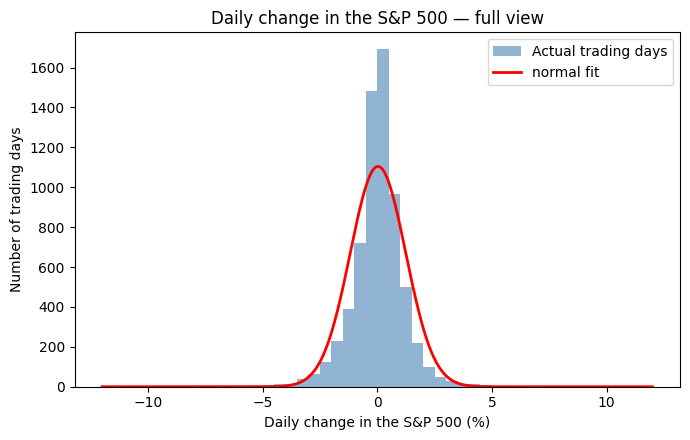

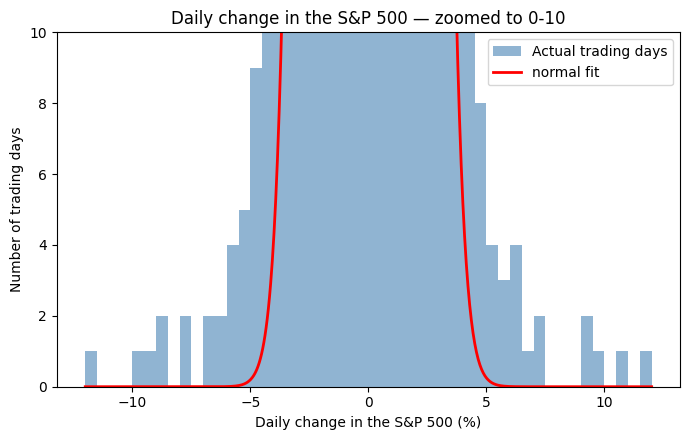

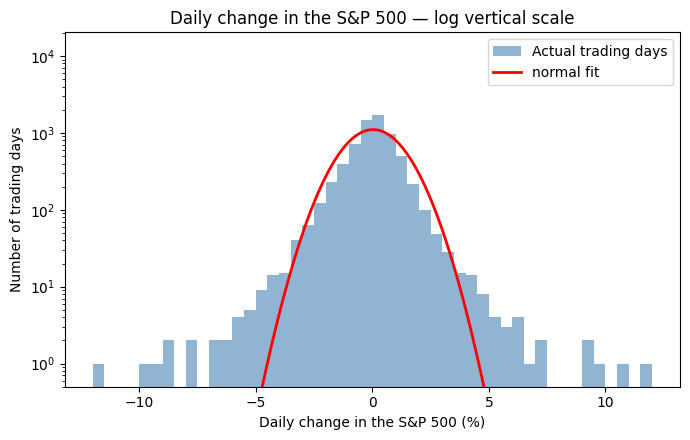

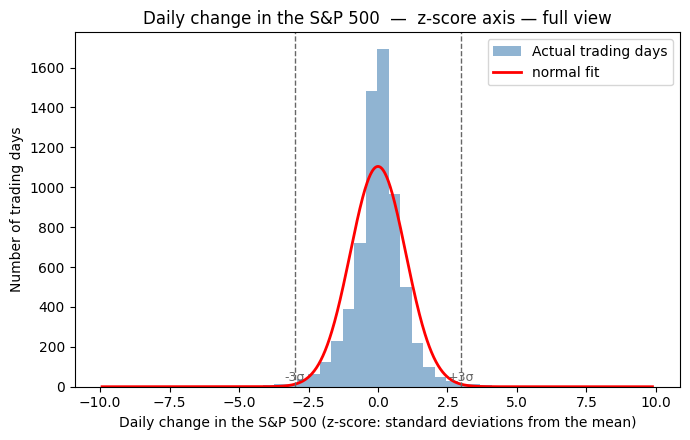

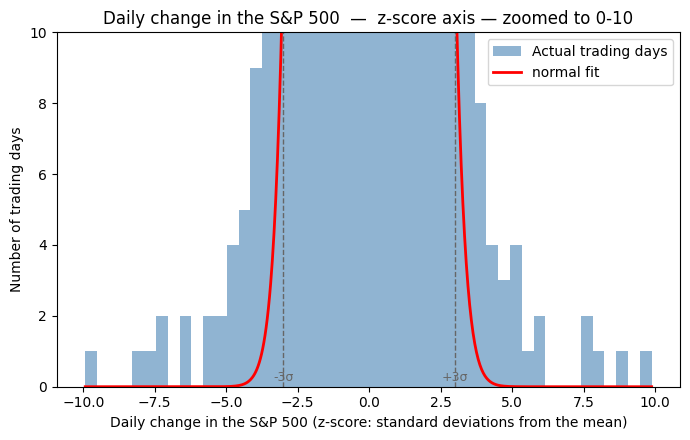

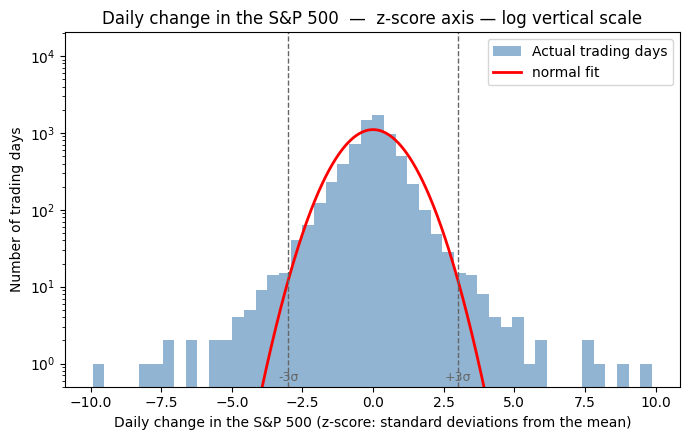

In [5]:
dt.analyze(stock)

## What to notice

- In the **full view** the normal fit tracks the central hump well.
- On the **log scale** and in the **z-score** panels the histogram has
  bars many standard deviations out where the normal fit has effectively
  dropped to zero.
- The summary table makes it quantitative: days beyond 3, 4, 5 sigma
  happen tens to hundreds of times more often than a normal predicts,
  and the excess kurtosis is large and positive.